# Find and continue the best step response: AIDI on nonlinear B737

This example uses the TensorAeroSpace SDK to define a physical experiment, tune a native adaptive controller, continue the same search with `resume()`, and save a checkpoint. `find_best_response()` spends an additional budget minimizing the chosen metric (CPI by default), even when an earlier stopping target has already been reached.

The aircraft starts at 10,000 ft / 600 ft/s. Pitch increases by 1° at 20 s; the full episode lasts 40 s with dt=0.01 s. AIDI identification remains active throughout the episode. Every candidate starts a fresh controller under the same simulation conditions. The tuning profile uses the native body-rate control interface, with an outer attitude-to-rate command.

The saved run uses 2,200 initial trials, 2,000 continuation trials and 120 further trials, with 12 worker processes. Reduce the budgets or worker count for a shorter demonstration; new search results may differ. Results mean **best tested feasible response**, not a proven global optimum. The selected response and the two additional validation amplitudes were replayed independently before publication.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from IPython.display import display
from tensoraerospace.optimization import ControllerTuner, Step, Float

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})

## 1. Set the experiment, requirements and search budgets

`Step(amplitude=1, at=20, unit="deg")` adds 1° to the trimmed initial pitch. Before the step, the reference holds that initial value. The native benchmark computes CPI from the complete step response; `normalize=True` scales each channel by its commanded step amplitude. It does not constrain CPI to [0, 1].

These accuracy requirements are **hard constraints**: every evaluated seed must meet them. A response outside the model envelope, an incomplete episode, nonfinite states or an unmet requirement cannot win. `target_cpi` only stops a search early when its best feasible CPI is low enough. Leaving a target unmet does not discard an otherwise feasible best result.

In [2]:
experiment = dict(
    env="NonlinearB737-v0",
    env_kwargs={"trim_at": (10000.0, 600.0), "dt": 0.01},
    reference={"theta": Step(amplitude=1.0, at=20.0, unit="deg")},
    controller="aidi",
    duration=40.0,
    seed=42,
)
constraints = {
    "relative_tail_max_error": 0.02,  # <= 2% of the commanded step
    "pre_step_relative_error": 0.02,
    "command_settling_time": 12.0,    # seconds after the step, 5% band
}
target_cpi = 0.3

budgets = (
    dict(initial=2200, resume=2000, best=120, unconstrained=120,
         genetic=120, multi=24, n_jobs=12)
)
display(pd.DataFrame([budgets], index=["Search budgets"]))

tuner = ControllerTuner(**experiment, method="tpe", constraints=constraints)
baseline = tuner.simulate()

,initial,resume,best,unconstrained,genetic,multi,n_jobs
Search budgets,2200,2000,120,120,120,24,12


## 2. Inspect the selected controller's parameters

For AIDI, the automatic space varies the inner-loop rate gain, filter cutoff, outer attitude gain, RLS covariance and `config.rls_sigma0`. `profile()` also lists native constructor paths for a custom search. Other controllers have their own parameter sets.

The optional `known_ihdp_params` dictionary is retained for switching the experiment to `controller="ihdp"`. It comes from an earlier iHDP search for this aircraft and step. It is used only for iHDP; the current AIDI study starts without that warm start. Do not pass actor/critic learning rates to AIDI.

In [3]:
profile = ControllerTuner.profile(experiment["controller"])
display(pd.DataFrame({"Search range": {
    name: repr(distribution) for name, distribution in profile["search_space"].items()
}}))

known_ihdp_params = {
    "actor_lr": 0.0011089721528085023,
    "critic_lr": 0.0987622995017457,
    "track_weight": 9.974992811899032,
    "gamma": 0.9944023883540949,
    "hidden_size": 16,
    "excitation_amplitude": 0.0011552319280603832,
    "actor_settings.learning_rate_decay": 0.9977777505481639,
    "critic_settings.learning_rate_decay": 0.9989690921428205,
}
initial_params = known_ihdp_params if tuner.controller == "ihdp" else None

,Search range
rate_gain,"FloatDistribution(high=10.0, log=True, low=0.5..."
cutoff_hz,"FloatDistribution(high=20.0, log=True, low=2.0..."
outer_gain,"FloatDistribution(high=1.0, log=True, low=0.1,..."
rls_cov_init,"FloatDistribution(high=10.0, log=True, low=0.1..."
config.rls_sigma0,"FloatDistribution(high=0.1, log=True, low=0.00..."


## 3. Start the study once

`optimize()` creates a new study. Run this cell once to start it; use the next cell to add attempts. TPE supports CPU process parallelism, with one fresh environment/controller per candidate. The progress bar displays the current best feasible score and an ETA. Annealing requires `n_jobs=1`.

If no candidate meets all hard constraints, inspect `tuner.diagnostics()`. `resume()` can add trials after that error without changing the requirements.

In [4]:
initial = tuner.optimize(
    n_trials=budgets["initial"],
    n_jobs=budgets["n_jobs"],
    target=target_cpi,
    initial_params=initial_params,
)
print("Initial selected parameters:", initial.best_params)
print("Initial normalized CPI:", initial.best_value)
print("Trials evaluated:", len(initial.study.trials))

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/optuna/samplers/_tpe/sampler.py:338: ExperimentalWarning: ``constant_liar`` option is an experimental feature. The interface can change in the future.
  warnings.warn(


Searching:   0%|          | 0/2200 [00:00, ETA ?]

Initial selected parameters: {'rate_gain': 3.843117143499538, 'cutoff_hz': 18.171249399594355, 'outer_gain': 0.9999717553981868, 'rls_cov_init': 0.2513641850878104, 'config.rls_sigma0': 0.0012036520670622775}
Initial normalized CPI: 0.5677131999803134
Trials evaluated: 2200


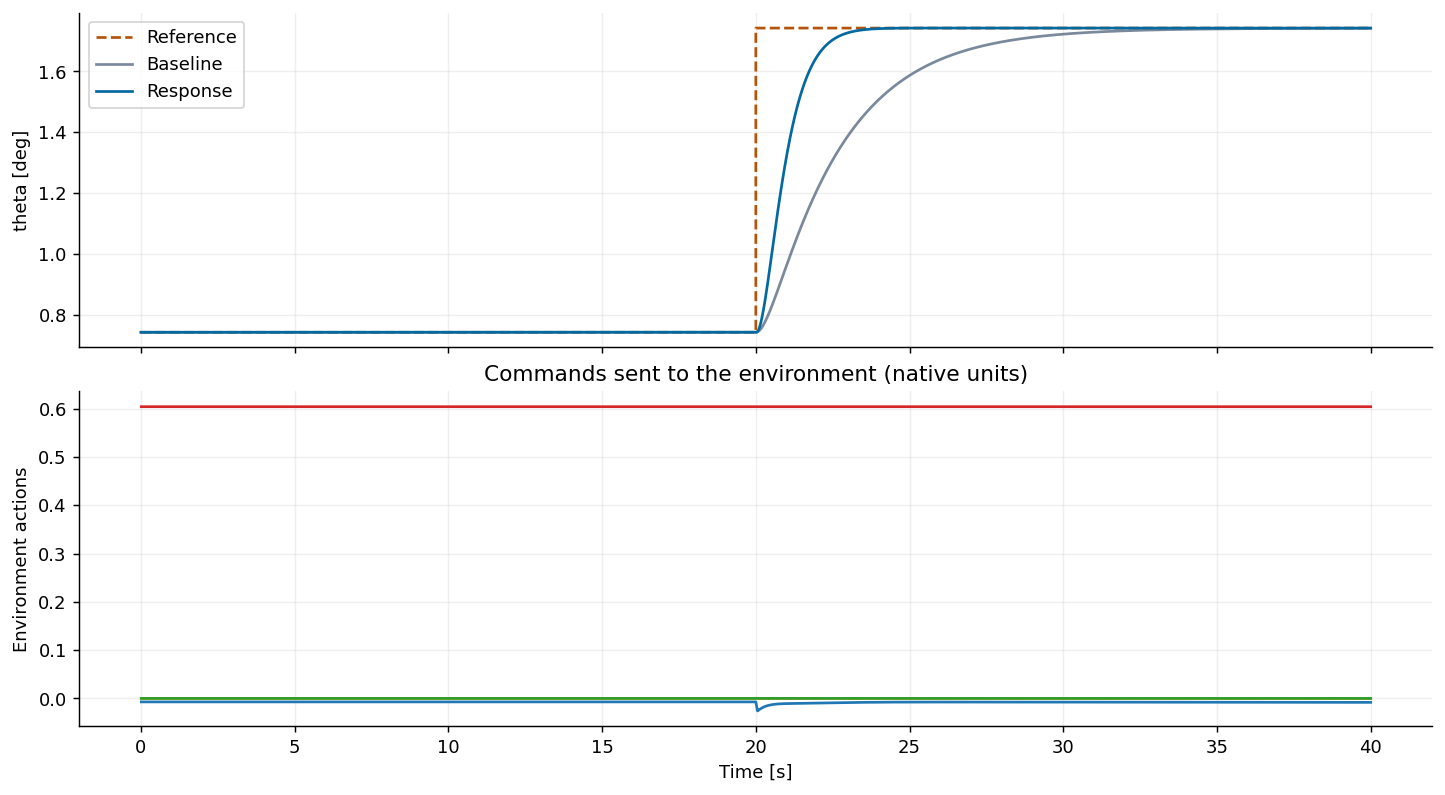

In [5]:
initial_figure = initial.plot_response(baseline=baseline)
plt.show()

## 4. Continue with `resume()`

`n_trials` now means **additional** attempts. History, the sampler's RNG and state, the best candidate, and the previous worker count remain available. Do not call `optimize()` again to continue: it starts over.

A supplied `target` uses the best result across the whole history. If that target was already reached, no additional candidates run. Omit `target` when you want to keep improving anyway. The environment, reference, metric and constraints must remain unchanged.

In [6]:
previous_trials = len(tuner.optimizer.study.trials)
resumed = tuner.resume(
    n_trials=budgets["resume"],
    target=target_cpi,
)
print("Additional trials:", len(resumed.study.trials) - previous_trials)
print("Total trials:", len(resumed.study.trials))
print("CPI before / after continuation:", initial.best_value, resumed.best_value)

Searching:   0%|          | 0/2000 [00:00, ETA ?]

Additional trials: 2000
Total trials: 4200
CPI before / after continuation: 0.5677131999803134 0.5677131999803134


## 5. Spend a budget on the best observed transient

`find_best_response()` starts a search when none exists and otherwise continues it. It minimizes the configured metric, CPI by default, with **no target threshold**. The call finishes on its trial/time budget or optional `patience` (attempts without an improvement). All hard constraints stay active.

This mode uses the existing optimizer, controller equations and CPI definition. A lower CPI does not prove that every individual response measure improved; inspect accuracy, overshoot and settling too.

In the saved AIDI run, CPI improved from the default profile's 3.51360 to 0.567713, and command settling time decreased from 7.77 s to 2.36 s. Continuation grew the history from 2,200 to 4,200 to 4,320 trials without improving that candidate. The target CPI=0.3 remains unmet. These are comparisons with the default profile on this experiment, not a global optimum or a comparison against a separately tuned controller.

Searching:   0%|          | 0/120 [00:00, ETA ?]

Best observed parameters: {'rate_gain': 3.843117143499538, 'cutoff_hz': 18.171249399594355, 'outer_gain': 0.9999717553981868, 'rls_cov_init': 0.2513641850878104, 'config.rls_sigma0': 0.0012036520670622775}
Best observed normalized CPI: 0.5677131999803134
Total evaluated trials: 4320


,cpi,command_settling_time,command_overshoot,relative_tail_max_error,pre_step_relative_error
Baseline,3.513600,7.77,0.000000,0.001022,8.011022e-14
Initial TPE search,0.567713,2.36,0.008232,0.000025,1.769184e-14
After resume,0.567713,2.36,0.008232,0.000025,1.769184e-14
Best observed response,0.567713,2.36,0.008232,0.000025,1.769184e-14


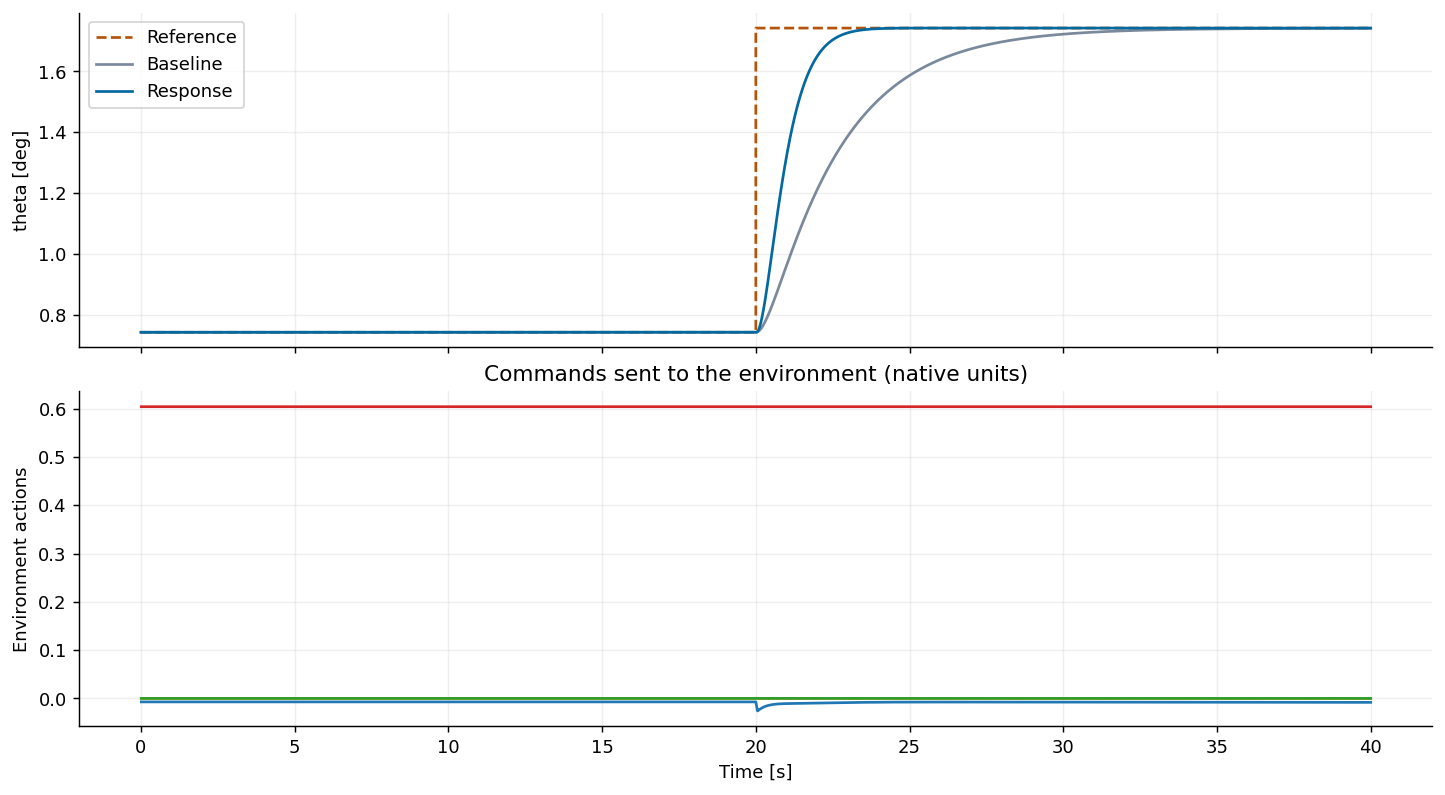

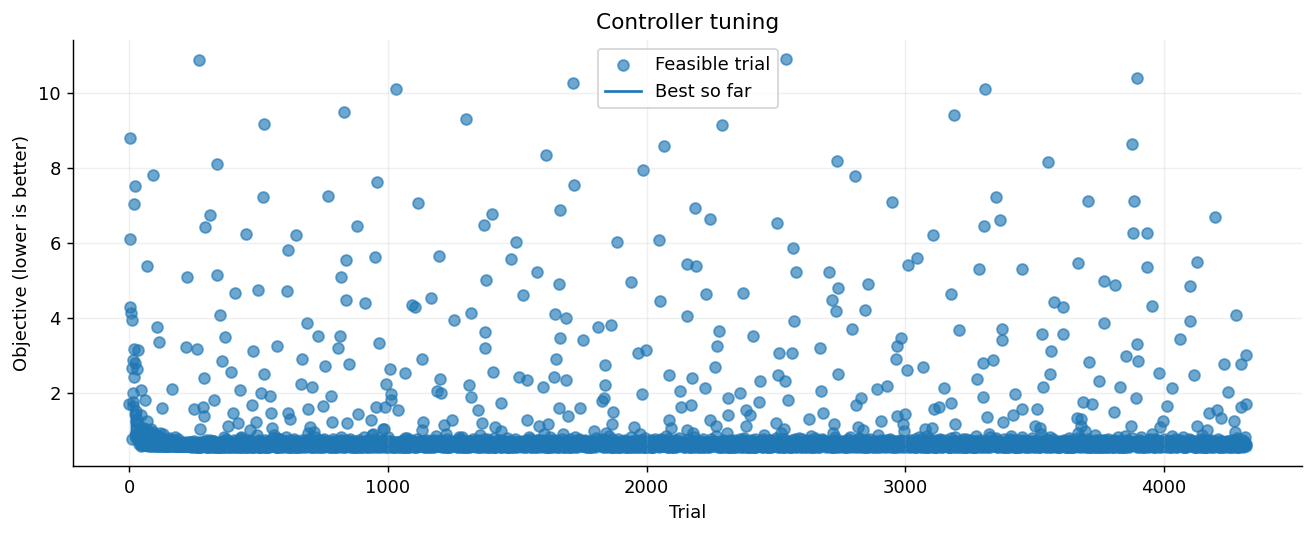

In [7]:
result = tuner.find_best_response(
    n_trials=budgets["best"],
    patience=None,  # Use the full additional budget
)
print("Best observed parameters:", result.best_params)
print("Best observed normalized CPI:", result.best_value)
print("Total evaluated trials:", len(result.study.trials))

keys = ["cpi", "command_settling_time", "command_overshoot",
        "relative_tail_max_error", "pre_step_relative_error"]
display(pd.DataFrame({
    "Baseline": baseline.metrics,
    "Initial TPE search": initial.best_run.metrics,
    "After resume": resumed.best_run.metrics,
    "Best observed response": result.best_run.metrics,
}).loc[keys].T)
result.plot_response(baseline=baseline)
plt.show()
result.plot_history()
plt.show()

### Search only for minimum CPI, without accuracy ceilings

For a pure CPI search, create a **separate** tuner with `constraints={}`. It will return the lowest CPI among complete physically admissible trials even if an accuracy goal is not met. Physical envelope, finite-state and actuator checks still apply. An existing constrained study is never silently relaxed or mixed with this new experiment.

The table explicitly checks the former accuracy requirements on the returned trajectory. Failing a reported goal means the candidate should not be accepted when that goal is mandatory.

In [8]:
cpi_tuner = ControllerTuner(
    **experiment, method="tpe", metric="cpi", constraints={},
)
cpi_only = cpi_tuner.find_best_response(
    n_trials=budgets["unconstrained"],
    n_jobs=budgets["n_jobs"],
    initial_params=result.best_params,
)
print("Lowest tested CPI without accuracy ceilings:", cpi_only.best_value)
quality_check = pd.DataFrame([
    {"Metric": name, "Measured": cpi_only.best_run.metrics[name],
     "Required maximum": bound,
     "Meets goal": (cpi_only.best_run.metrics[name] is not None
                    and np.isfinite(cpi_only.best_run.metrics[name])
                    and cpi_only.best_run.metrics[name] <= bound)}
    for name, bound in constraints.items()
]).set_index("Metric")
display(quality_check)

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/optuna/samplers/_tpe/sampler.py:338: ExperimentalWarning: ``constant_liar`` option is an experimental feature. The interface can change in the future.
  warnings.warn(


Searching:   0%|          | 0/120 [00:00, ETA ?]

Lowest tested CPI without accuracy ceilings: 0.5677131999803134


,Measured,Required maximum,Meets goal
Metric,,,
relative_tail_max_error,2.523823e-05,0.02,True
pre_step_relative_error,1.769184e-14,0.02,True
command_settling_time,2.360000e+00,12.00,True


## 6. Save the search and restart Jupyter

Save after the search stops. The checkpoint contains the experiment, all trials and the sampler state. It continues parameter optimization; selected neural-network weights are not stored. Load your own trusted pickle files in a compatible Python/SDK/Optuna environment.

`result.save("report.json")` exports a report, while `save_checkpoint()` creates a resumable search.

In [ ]:
checkpoint = Path("adaptive-controller-search.pkl")
tuner.save_checkpoint(checkpoint)
print("Saved search checkpoint:", checkpoint.resolve())

In a **new kernel**, run the following to continue the constrained TPE search:

```python
from tensoraerospace.optimization import ControllerTuner

tuner = ControllerTuner.load_checkpoint("adaptive-controller-search.pkl")
result = tuner.resume(n_trials=120)  # Previous worker count and sampler state
# Or: result = tuner.find_best_response(n_trials=120)
result.plot_response()
result.plot_history()
```

Loading runs no simulations. Changing aircraft settings, channels, dt, constraints or metric requires a new study. `resume()` rejects such changes before evaluating new candidates.

## 7. Try genetic search with the same controller

This creates another study using Optuna NSGA-II and initializes it from the feasible AIDI candidate found above. The initial values belong to the selected controller. This demonstrates the API; it is not an equal-budget comparison of search methods, because genetic search receives a warm start.

In [9]:
genetic_tuner = ControllerTuner(
    **experiment,
    method="genetic",
    method_options={"population_size": 4},
    constraints=constraints,
)
genetic = genetic_tuner.find_best_response(
    n_trials=budgets["genetic"],
    n_jobs=min(budgets["n_jobs"], 4),
    initial_params=result.best_params,
)
display(pd.DataFrame({
    "TPE with continuation": result.best_run.metrics,
    "Warm-started genetic search": genetic.best_run.metrics,
}).loc[keys].T)

Searching:   0%|          | 0/120 [00:00, ETA ?]

,cpi,command_settling_time,command_overshoot,relative_tail_max_error,pre_step_relative_error
TPE with continuation,0.567713,2.36,0.008232,0.000025,1.769184e-14
Warm-started genetic search,0.567713,2.36,0.008232,0.000025,1.769184e-14


## 8. Several commanded states

Use one step per named state. The AIDI adapter converts the pitch and roll commands to body-rate commands. The objective is the mean normalized channel CPI; `theta.cpi` and `phi.cpi` remain available separately.

This is a new experiment with no accuracy ceilings. The single-channel result supplies starting parameters; its study/history is not reused. Inspect every channel's error and settling time.

In the saved 24-trial run, both channels settle within the ±5% command band in 2.35 s. Maximum tail errors are about 0.0027% for pitch and 0.0060% for roll. Both are within a 2% accuracy goal in this experiment. If another run displays NaN for settling time, the response did not settle within the simulated horizon.

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/optuna/samplers/_tpe/sampler.py:338: ExperimentalWarning: ``constant_liar`` option is an experimental feature. The interface can change in the future.
  warnings.warn(


Searching:   0%|          | 0/24 [00:00, ETA ?]

,cpi,command_settling_time,relative_tail_max_error
theta,0.556807,2.35,0.000027
phi,0.568038,2.35,0.000060


Mean channel CPI: 0.5624227082544488


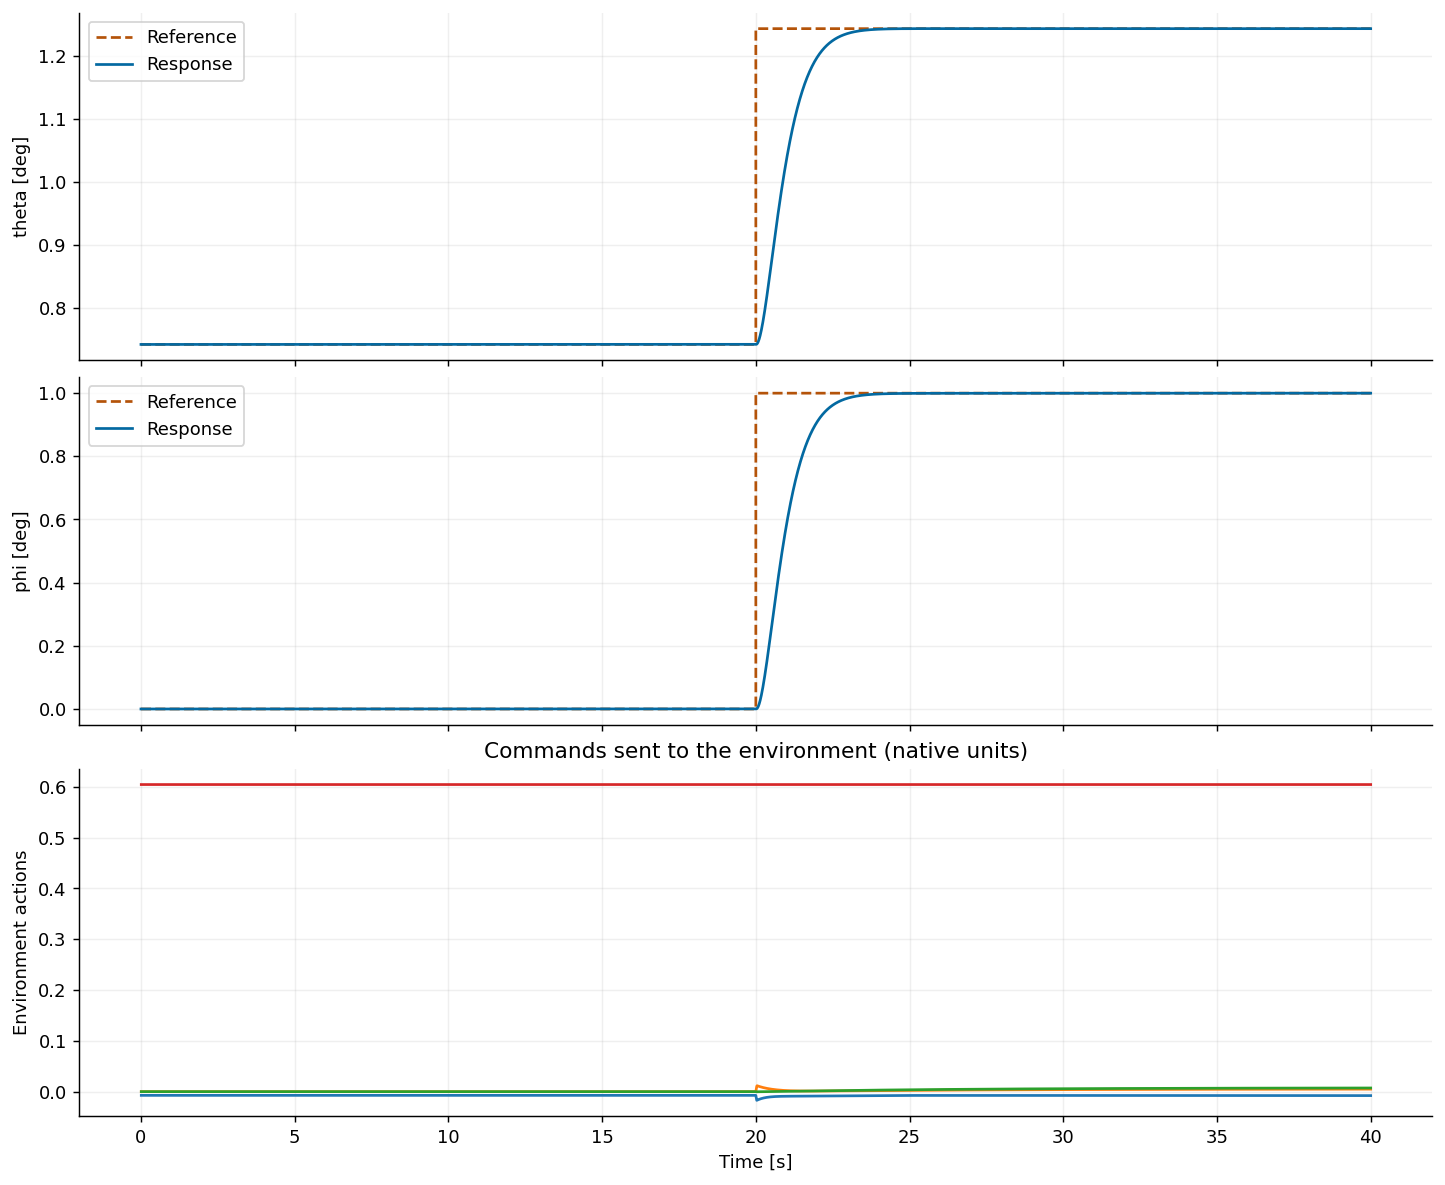

In [10]:
multi_tuner = ControllerTuner(
    **{**experiment, "reference": {
        "theta": Step(0.5, at=20.0, unit="deg"),
        "phi": Step(1.0, at=20.0, unit="deg"),
    }},
    method="tpe",
)
multi = multi_tuner.find_best_response(
    n_trials=budgets["multi"],
    n_jobs=budgets["n_jobs"],
    initial_params=result.best_params,
)
display(pd.DataFrame({
    state: {key: multi.best_run.metrics[f"{state}.{key}"]
            for key in ["cpi", "command_settling_time", "relative_tail_max_error"]}
    for state in multi.best_run.states
}).T)
print("Mean channel CPI:", multi.best_value)
multi.plot_response()
plt.show()

## 9. Validate different amplitudes and a new seed

Replay the selected settings on cases not used by the constrained single-channel TPE search. Every case creates a fresh controller and environment, and online adaptation stays enabled. This tests transfer of hyperparameters; it does not load a trained policy.

The saved −1° and +0.5° steps at seed 17 both meet the original accuracy limits: command settling times are 2.36 s and 2.35 s, and maximum tail errors are below 0.0025% of the step. These two healthy-aircraft cases do not establish robustness to failures, sensor noise or other flight conditions.

In [11]:
validation = {}
for amplitude in (-1.0, 0.5):
    check = ControllerTuner(**{
        **experiment,
        "reference": {"theta": Step(amplitude, at=20.0, unit="deg")},
    })
    run = check.simulate(result.best_params, seed=17)
    validation[f"{amplitude:+g} deg, seed=17"] = {
        key: run.metrics[key] for key in keys
    }
display(pd.DataFrame(validation).T)

,cpi,command_settling_time,command_overshoot,relative_tail_max_error,pre_step_relative_error
"-1 deg, seed=17",0.567585,2.36,0.008174,0.000024,1.769184e-14
"+0.5 deg, seed=17",0.556772,2.35,0.008219,0.000025,3.538367e-14


## 10. Controller, metric and parameter selection

The same API accepts `iadp`, `imgdhp` (`im_gdhp`), `ihdp`, `et_dhp`, `aa_indi`, `aidi`, `hdp` and `mpc`, subject to their documented environment compatibility. `ControllerTuner.available_controllers()` lists combinations; `ControllerTuner.profile(name)` lists default ranges and native parameter paths. iHDP currently supports one online episode in this declarative profile.

Choose another metric in the constructor, for example `metric="iae"` or `metric="theta.cpi"`; `find_best_response()` honors that metric. For iHDP, a custom search can include:

```python
search_space = {
    "actor_lr": Float(1e-5, 0.1, log=True),
    "critic_lr": Float(1e-5, 0.1, log=True),
    "track_weight": Float(0.1, 10.0, log=True),
    "actor_settings.learning_rate_decay": Float(0.995, 1.0),
    "critic_settings.learning_rate_decay": Float(0.995, 1.0),
}
```

Fixed settings go in `controller_options`. Preserve environment, step timing, learning budget and seeds when comparing candidate parameters. Additional trials can improve the best score or leave it unchanged; neither CPI=0 nor a universal controller is guaranteed.